In [1]:
import re
import pandas as pd

In [2]:
def parse_large_log_file(file_path):
    # Optimized pattern - website is at end of line after 'from '
    pattern = re.compile(
        r'(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3}).*?'
        r'Success: Extracted (?P<num_urls>\d+) URLs from (?P<website>.+)$'
    )
    
    data = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            match = pattern.search(line.strip())
            if match:
                data.append({
                    'timestamp': match.group('timestamp').replace(',', '.'),  # Convert comma to decimal for pandas
                    'num_urls': int(match.group('num_urls')),
                    'website': match.group('website').rstrip()
                })
    
    df = pd.DataFrame(data)
    
    # Convert timestamp to datetime with milliseconds
    df['datetime'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S.%f')
    
    # Set datetime as index (optional)
    df = df.set_index('datetime').sort_index()
    
    return df

In [3]:
# Process the large log file
log_file = 'logs/execution_20250426220043.log'
df = parse_large_log_file(log_file)

# Results analysis
print(f"Found {len(df)} URL extraction events")
print("\nTop 5 results:")
print(df.head())
print("\nStatistics:")
print(f"Total URLs extracted: {df['num_urls'].sum():,}")
print(f"Unique websites: {df['website'].nunique()}")


Found 100011 URL extraction events

Top 5 results:
                                       timestamp  num_urls  \
datetime                                                     
2025-04-26 22:00:43.686  2025-04-26 22:00:43.686       435   
2025-04-26 22:00:43.687  2025-04-26 22:00:43.687         0   
2025-04-26 22:00:43.804  2025-04-26 22:00:43.804        22   
2025-04-26 22:00:43.856  2025-04-26 22:00:43.856       334   
2025-04-26 22:00:43.963  2025-04-26 22:00:43.963        66   

                                                                   website  
datetime                                                                    
2025-04-26 22:00:43.686                              https://ge.globo.com/  
2025-04-26 22:00:43.687                        https://www.bol.uol.com.br/  
2025-04-26 22:00:43.804          https://ge.globo.com/ginastica-artistica/  
2025-04-26 22:00:43.856                       https://www.techtudo.com.br/  
2025-04-26 22:00:43.963  https://www.techtudo.com.br

In [4]:
len(df)

100011

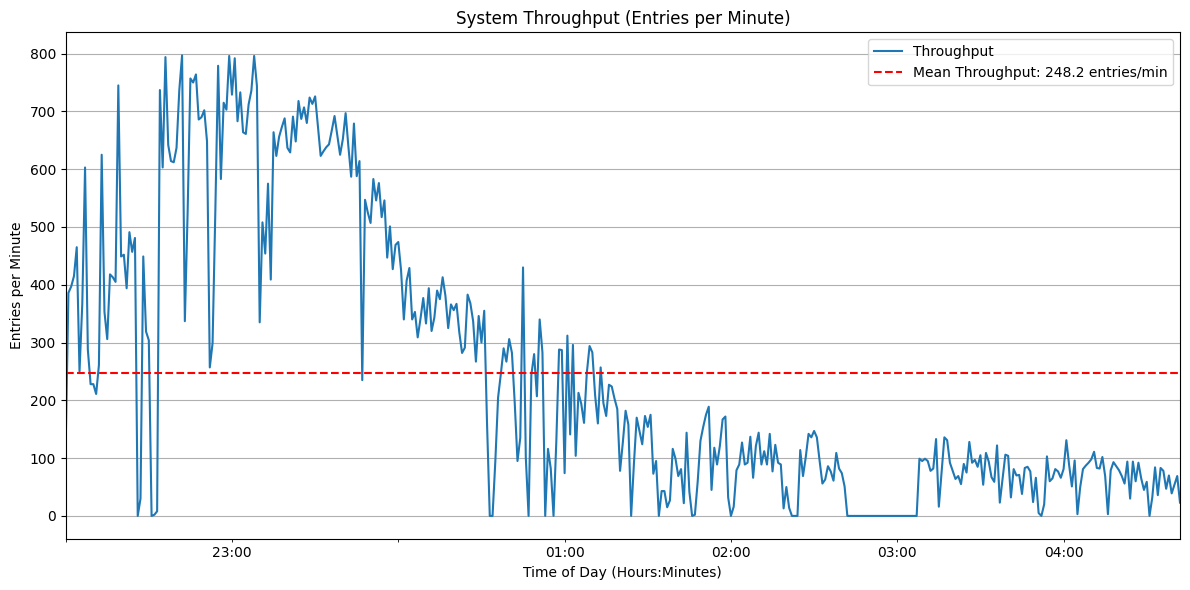

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Resample to count entries per minute (throughput)
throughput_per_minute = df.resample('1min').size()  # '1T' means 1 minute

# Calculate mean throughput
mean_throughput = throughput_per_minute.mean()

# Create the plot
plt.figure(figsize=(12, 6))
ax = plt.gca()  # Get current axis

# Plot throughput
throughput_per_minute.plot(kind='line', ax=ax, label='Throughput')

# Add mean line
ax.axhline(mean_throughput, color='red', linestyle='--', 
           label=f'Mean Throughput: {mean_throughput:.1f} entries/min')

# Format x-axis to show only hours
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))  # Show every hour

# Customize labels and title
plt.title('System Throughput (Entries per Minute)')
plt.xlabel('Time of Day (Hours:Minutes)')
plt.ylabel('Entries per Minute')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.show()

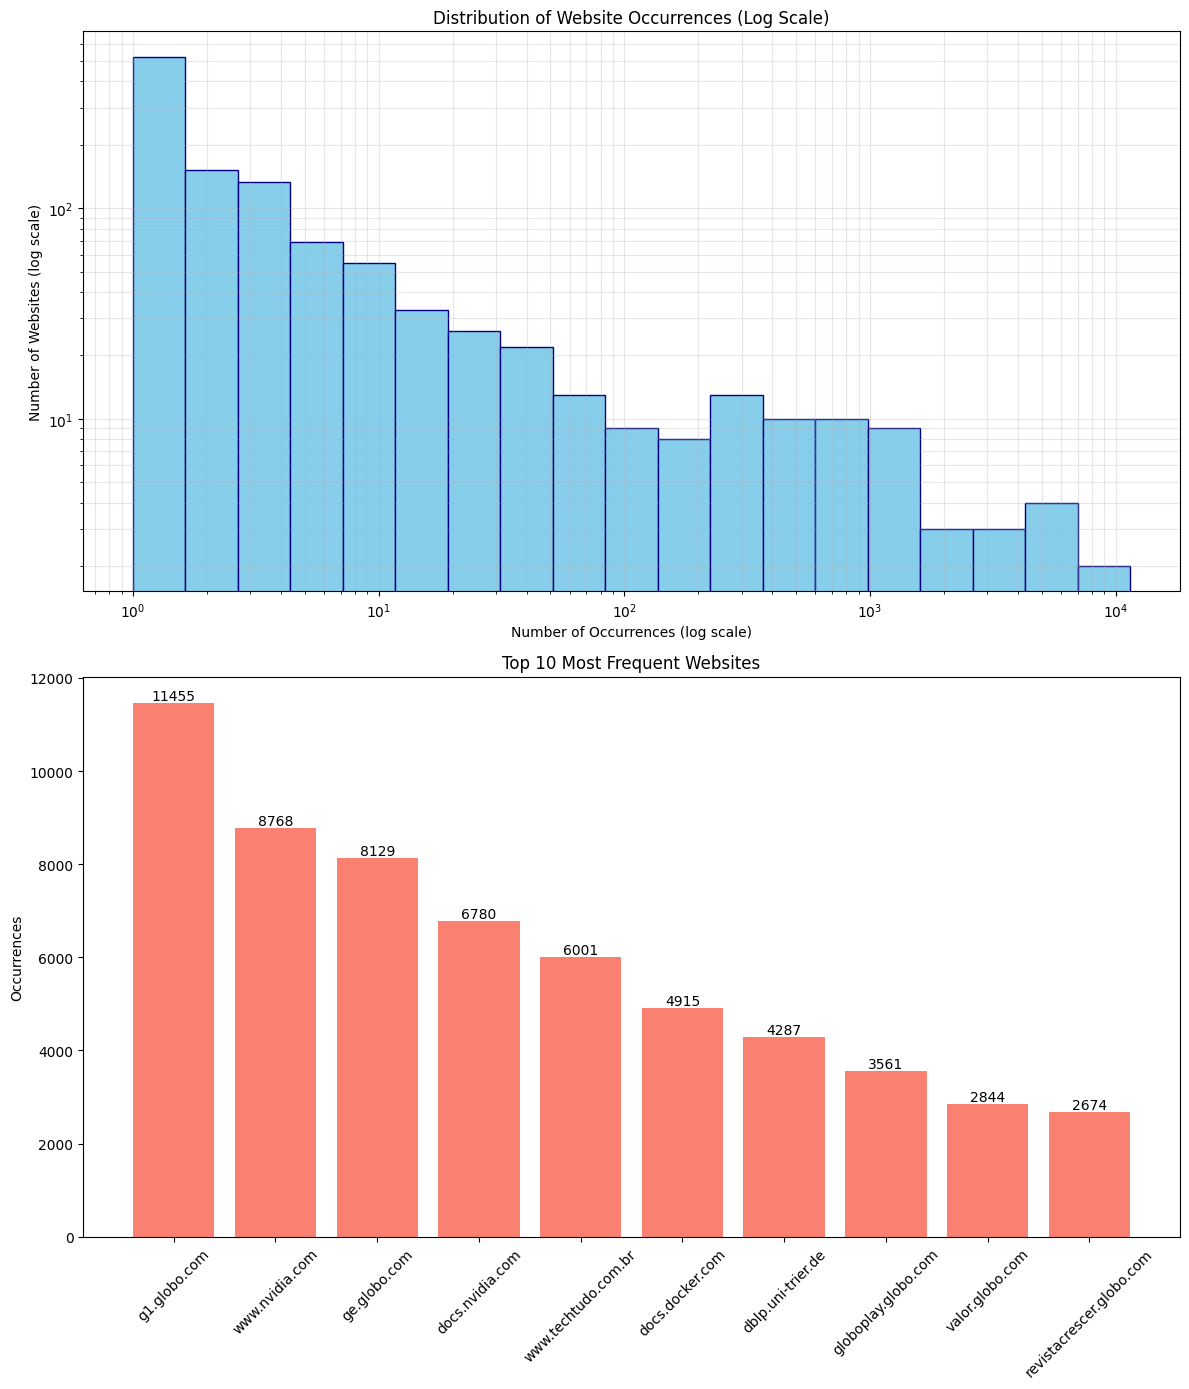

In [6]:
import matplotlib.pyplot as plt
from urllib.parse import urlparse
import numpy as np

# Extract domain names
df['netloc'] = df['website'].apply(lambda x: urlparse(x).netloc)

# Get counts per domain
domain_counts = df['netloc'].value_counts()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

# 1. Log-scale Histogram
ax1.hist(domain_counts, 
         bins=np.logspace(0, np.log10(domain_counts.max()), 20),
         color='skyblue', 
         edgecolor='navy',
         log=True)
ax1.set_xscale('log')
ax1.set_title('Distribution of Website Occurrences (Log Scale)')
ax1.set_xlabel('Number of Occurrences (log scale)')
ax1.set_ylabel('Number of Websites (log scale)')
ax1.grid(True, which="both", ls="-", alpha=0.3)

# 2. Top 10 Websites
top_10 = domain_counts.head(10)
bars = ax2.bar(top_10.index, top_10.values, color='salmon')
ax2.set_title('Top 10 Most Frequent Websites')
ax2.set_ylabel('Occurrences')
ax2.tick_params(axis='x', rotation=45)

# Add exact counts on top of bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

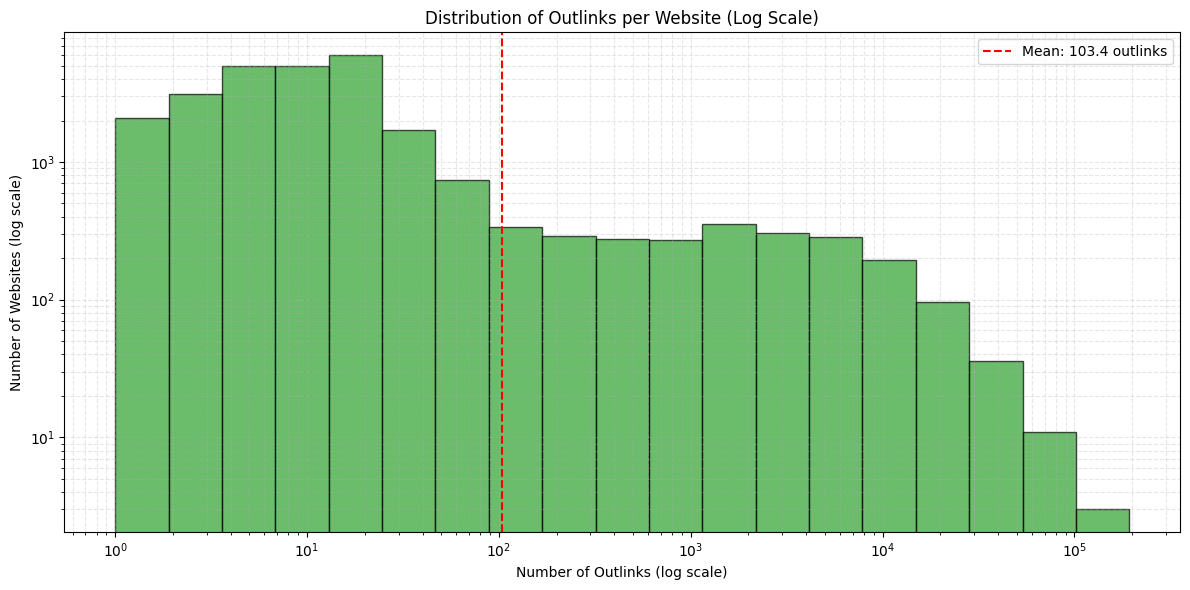

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Create histogram with logarithmic bins
plt.hist(df['num_urls'], 
         bins=np.logspace(np.log10(1), np.log10(df['num_urls'].max()+1), 20),
         color='#2ca02c',
         edgecolor='black',
         alpha=0.7)

# Log-scale formatting
plt.xscale('log')
plt.yscale('log')  # Remove this line if you want linear y-axis
plt.grid(True, which="both", ls="--", alpha=0.3)

# Labels and title
plt.title('Distribution of Outlinks per Website (Log Scale)')
plt.xlabel('Number of Outlinks (log scale)')
plt.ylabel('Number of Websites (log scale)')

# Add median line
mean = df['num_urls'].mean()
plt.axvline(mean, color='red', linestyle='--',
           label=f'Mean: {mean:.1f} outlinks')
plt.legend()

plt.minorticks_on()
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Processing file: output_89.warc.gz
Processing file: output_99.warc.gz
Processing file: output_30.warc.gz
Processing file: output_20.warc.gz
Processing file: output_52.warc.gz
Processing file: output_42.warc.gz
Processing file: output_5.warc.gz
Processing file: output_74.warc.gz
Processing file: output_64.warc.gz
Processing file: output_16.warc.gz
Processing file: output_90.warc.gz
Processing file: output_80.warc.gz
Processing file: output_29.warc.gz
Processing file: output_39.warc.gz
Processing file: output_65.warc.gz
Processing file: output_75.warc.gz
Processing file: output_4.warc.gz
Processing file: output_100.warc.gz
Processing file: output_17.warc.gz
Processing file: output_38.warc.gz
Processing file: output_28.warc.gz
Processing file: output_81.warc.gz
Processing file: output_91.warc.gz
Processing file: output_21.warc.gz
Processing file: output_31.warc.gz
Processing file

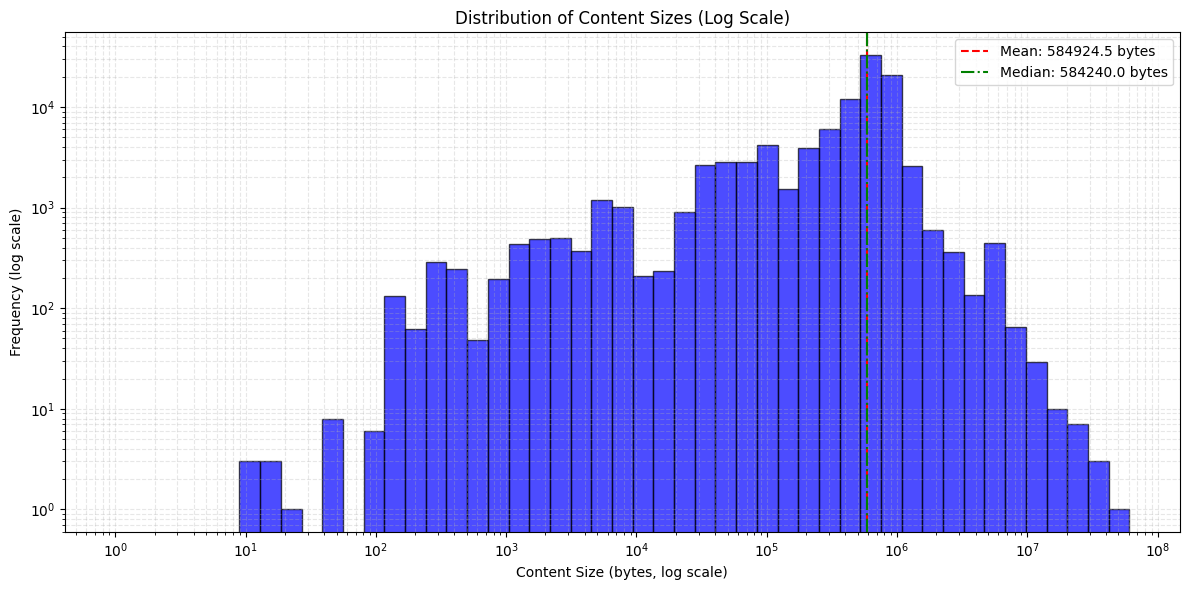

In [9]:
!pip install warcio
from warcio.archiveiterator import ArchiveIterator
import os
import numpy as np
import gzip
import matplotlib.pyplot as plt

# Directory containing .warc.gz files
warc_dir = 'warc'

# List to store content sizes
content_sizes = []

# Iterate over all .warc.gz files in the directory
for file_name in os.listdir(warc_dir):
    if file_name.endswith('.warc.gz'):
        print(f"Processing file: {file_name}")
        file_path = os.path.join(warc_dir, file_name)
        with gzip.open(file_path, 'rb') as f:
            for record in ArchiveIterator(f):
                if record.rec_type == 'response':  # Only process response records
                    content_sizes.append(len(record.content_stream().read()))

# Create a histogram of content sizes
plt.figure(figsize=(12, 6))
plt.hist(content_sizes, 
         bins=np.logspace(np.log10(1), np.log10(max(content_sizes)+1), 50),
         color='blue', 
         edgecolor='black', 
         alpha=0.7)

# Log-scale formatting
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.3)
# Calculate median
median = np.median(content_sizes)
mean = np.mean(content_sizes)

# Add mean and median lines
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.1f} bytes')
plt.axvline(median, color='green', linestyle='-.', label=f'Median: {median:.1f} bytes')
plt.legend()
# Labels and title
plt.title('Distribution of Content Sizes (Log Scale)')
plt.xlabel('Content Size (bytes, log scale)')
plt.ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()
